Not necessarily ordered
- [DONE] Get, filter, transform NYSE stonk hist data
- Do the Gurobi translation
- Sketch \algorithm
- Make list from biblio of temptative valuable demonstrations
- Paper will have tests with data, using 10y (moving 5y>1y), and also tests with weird PDFs


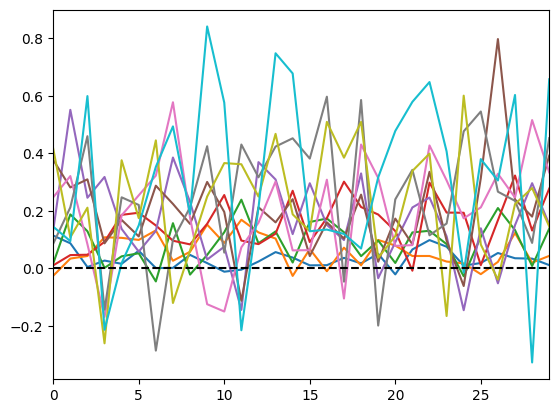

In [1]:
## General Parameter Definition

import numpy as np
import matplotlib.pyplot as plt

n, m = 30, 10
i = np.arange(1, m+1)
np.random.seed(1)
phi = 0.02 * np.random.normal(size=(n, m))
zeta = 0.03*i + 0.025*i*np.random.normal(size=(n, m))
zhat = np.maximum(phi + zeta, -1)         # historical data of yearly return

epsilon = 0.01                          # radius of the Wasserstein ball
rho = 10                                  # risk-aversion coefficient
alpha = 0.2                               # confidence level

a1, b1 = -1, rho                          # coefficients of the piecewise expression
a2, b2 = -1 - rho/alpha, rho - rho/alpha  # coefficients of the piecewise expression

#print(zhat)
plt.plot(zhat)
plt.plot([0,n-1],[0,0],linestyle='dashed',color='black')
plt.xlim([0,n-1])
plt.show()

[*********************100%%**********************]  43 of 43 completed


First selection: 43
Index(['AAL', 'AAPL', 'AMD', 'AMZN', 'BAC', 'BBD', 'CCL', 'CLSK', 'CSCO',
       'DELL', 'ERIC', 'F', 'FCX', 'GERN', 'GME', 'GOLD', 'GOOGL', 'HPE',
       'INTC', 'ITUB', 'KGC', 'LYG', 'MARA', 'MNST', 'NCLH', 'NIO', 'NVAX',
       'NVDA', 'PARA', 'PBR', 'PFE', 'PLUG', 'RIG', 'RIOT', 'SIRI', 'SLB',
       'SWN', 'T', 'TSLA', 'UAA', 'VALE', 'WBD', 'XOM'],
      dtype='object', name='Ticker')
Of these, how many have at least 10y history: 38
Of these how many never go outside (-50%,+50%) month-to-month: 24
Shape of monthly return data: (120, 24)
Date
2014-07    0.041007
2014-08   -0.037030
2014-09    0.009104
2014-10   -0.066305
2014-11    0.033322
2014-12   -0.031067
2015-01   -0.019558
2015-02    0.241118
2015-03   -0.001128
2015-04    0.050334
2015-05    0.082987
2015-06    0.013286
2015-07    0.106587
2015-08    0.083048
2015-09    0.004804
2015-10    0.087891
2015-11    0.160482
2015-12    0.017587
2016-01   -0.101904
2016-02   -0.117195
2016-03    0.078689
2016-04

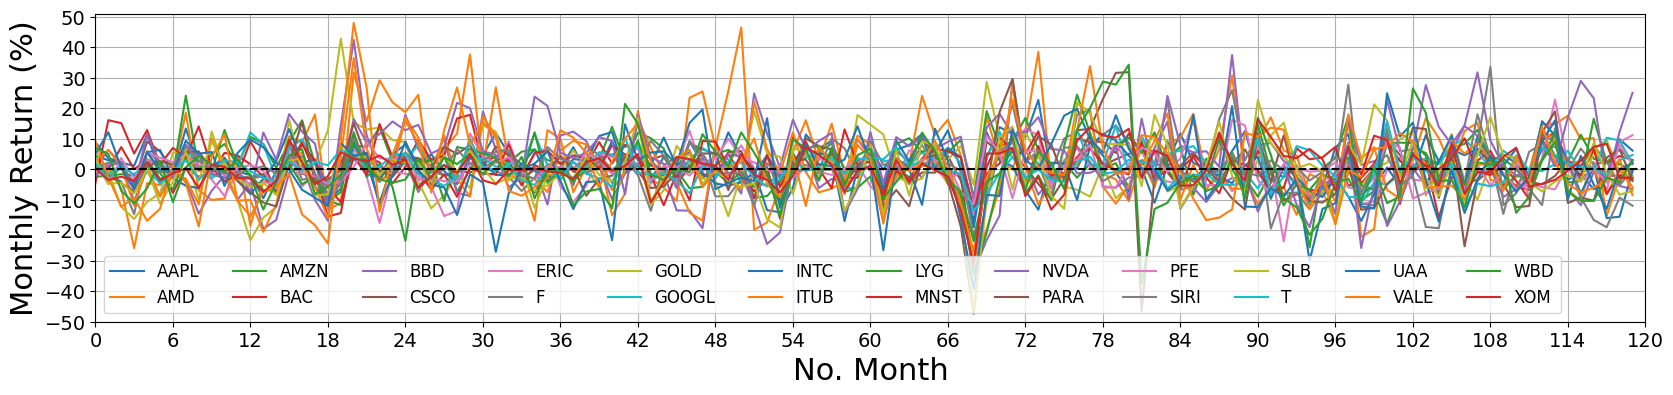

(2, 24)

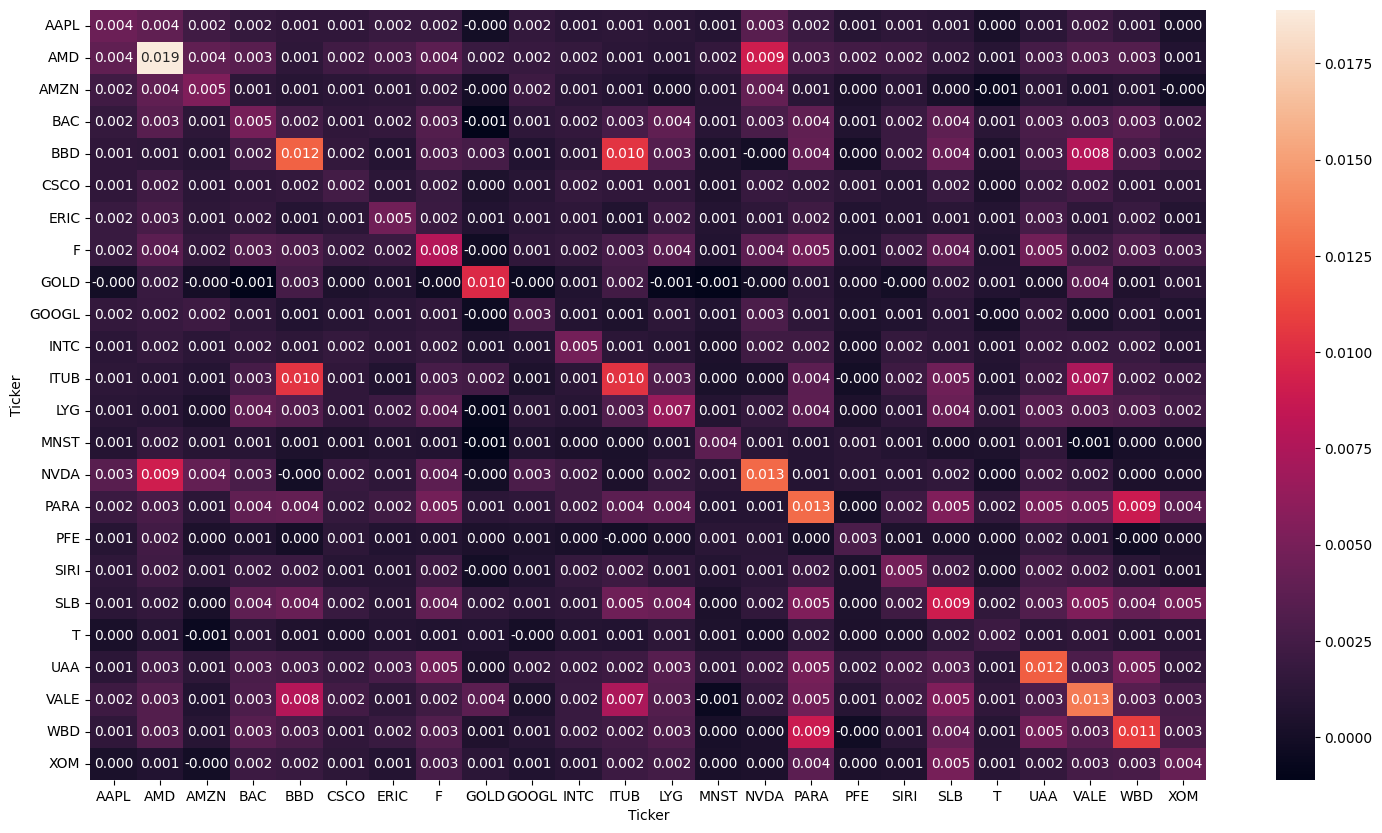

In [1]:
# Using NYSE Test Data

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
top25vol=['MARA','TSLA','GME','CCL','AMD','INTC','NVDA','AAPL','F','AAL','CLSK','PFE','GOLD','NIO','RIG','RIOT','PLUG','BBD','SIRI','T','VALE','AMZN','FCX','HPE','DELL','KGC','BAC','MNST','WBD','SWN','LYG','PARA','GERN','XOM','CSCO','ITUB','NVAX','ERIC','GOOGL','NCLH','UAA','PBR','SLB']
data = yf.download(" ".join(top25vol), period="10y")
data["Adj Close"]
#Now to filter the data
df=pd.DataFrame(data["Close"],index=None)
print("First selection: "+str(len(df.columns)))
print(df.columns)
df.dropna(axis=1,inplace=True)
df_monthly=df.groupby(pd.PeriodIndex(df.index, freq="M")).mean()
monthreturns=df_monthly.pct_change()
monthreturns.dropna(axis=0,inplace=True)
monthreturns=monthreturns.loc[:,~(abs(monthreturns)>0.5).any()]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print("Of these, how many have at least 10y history: "+str(len(df.columns)))
    print("Of these how many never go outside (-50%,+50%) month-to-month: "+str(len(monthreturns.columns)))
    print("Shape of monthly return data: "+str(monthreturns.shape))
    print(monthreturns['AMZN'])

# General Parameter Definition with NYSE Data
assets=monthreturns.columns.tolist()
zhat=monthreturns.to_numpy()            # historical data of yearly return
(n, m) = zhat.shape

epsilon = 0.01                          # radius of the Wasserstein ball
rho = 10                                # risk-aversion coefficient
alpha = 0.2                             # confidence level

a1, b1 = -1, rho                          # coefficients of the piecewise expression
a2, b2 = -1 - rho/alpha, rho - rho/alpha  # coefficients of the piecewise expression

print(f"a=[{a1},{a2}], b=[{b1},{b2}]")
plt.figure(figsize=(20,4))
plt.plot(zhat*100)
plt.plot([0,n],[0,0],linestyle='dashed',color='black')
plt.xlim([0,n])
plt.ylim([-50,51])
plt.legend(monthreturns.columns,loc="lower left",ncol=12,prop={'size': 12},)
plt.ylabel("Monthly Return (%)",fontsize=22)
plt.xlabel("No. Month",fontsize=22)
plt.yticks([-50+i*10 for i in range(11)],fontsize=14)
plt.xticks([i*6 for i in range(21)],fontsize=14)
plt.grid(visible=True)
plt.show()

import seaborn as sn
plt.figure(figsize=(18,10))
covmat=pd.DataFrame.cov(monthreturns)
sn.heatmap(covmat,fmt='.3f',annot=True)

(zhat[12:14,:]).shape

### Original Problem

\begin{align}
\min~&\sup\limits_{\mathbb{P}\in\mathcal{F}(\epsilon)} \mathbb{E}_{\mathbb{P}} \left[-\pmb{z}^{\top}\pmb{x} + \rho\mathbb{P}\text{-CVaR}_\alpha[-\pmb{z}^{\top}\pmb{x}]\right]\\
\min~&\sup\limits_{\mathbb{P}\in\mathcal{F}(\epsilon)} \mathbb{E}_{\mathbb{P}} \left[-\pmb{z}^{\top}\pmb{x} + \rho\left(\tau + \frac{1}{\alpha}\max\left\{-\pmb{z}^{\top}\pmb{x} - \tau, 0\right\}\right)\right] \\
\text{s.t.} ~&\pmb{1}^{\top}\pmb{x} = 1 \\
&\pmb{x}\in\mathbb{R}_+^m
\end{align}

Where the Conditional Value at Risk of a portfolio, represented by $\mathbb{P}\text{-CVaR}_\alpha[-z^Tx]$, is the expected value of the portfolio losses above a certain threshold which will not be exceeded with a confidence of $\beta=1-\alpha$, given a probability distribution $\mathbb{P}$. $x$ is a decision vector consisting of percentages of investment allocation on the $m$ assets of a capital market, $z$ is the corresponding periodic (e.g. montly, yearly) asset return random vector, $\rho$ is the investor's risk aversion (), $\beta$ is the confidence level of the CVaR (e.g. 0.9, 0.95), $\tau$ is the return threshold


### LP Reformulation

\begin{align}
\min ~&\lambda \epsilon + \frac{1}{n}\sum\limits_{i=1}^n s_i \\
\text{s.t.} ~&\sum\limits_{i=1}^m x_i = 1 & \\
&x_i \geq 0, &\forall i \in [m] \\
&b_k \tau + a_k \hat{\pmb{z}}_j^{\top}\pmb{x} + \pmb{\gamma}_{jk}^{\top}(\pmb{d} - \pmb{C}\hat{\pmb{z}}_j) \leq s_j &\forall j \in [n], \forall k \in [K] \\
&\|\pmb{C}^{\top}\pmb{\gamma}_{jk} - a_k\pmb{x}\|_{\infty} \leq \lambda \\
&\pmb{\gamma}_{jk} \in \mathbb{R}_{+}^{m} & \forall j \in [n], \forall k \in [K]
\end{align}

### Overleaf shit

\begin{align}
    \min_{x\geq\mathbf{0}} \sup_{\mathbb{P}}~&\mathbb{E}^\mathbb{P}[\max\{-\xi^Tx+\rho \tau,\nonumber\\
    &-(1+\rho/\alpha)\xi^Tx+\rho(1-1/\alpha)\tau)\}]\\
    &\text{s.t.}~ \mathbf{1}^T\mathbf{x}=1\\
    &\text{s.t.}~ d_W(\mathbb{P},\hat{\mathbb{Q}})\leq r_W
\end{align}

Reformulated to:
\begin{align}
    \Rightarrow &\min_{x,\lambda,\gamma,\tau,s} \lambda r_W + \sum^N_i q_is_i\\
    &\text{s.t.}~ \mathbf{1}^T\mathbf{x}=1\\
    &x_i\geq0 ~\forall i\\
    \rho\tau-&\hat{\xi}^T_j x + \gamma_{j1}^T(\mathbf{1}-\hat{\xi}_j)\leq s_j ~\forall j\\
    \rho(1-&\frac{1}{\alpha})\tau-(1-\frac{\rho}{\alpha})\hat{\xi}^T_j x + \gamma_{j2}^T(\mathbf{1}-\hat{\xi}_j)\leq s_j ~\forall j\\
    &\gamma_{j1},\gamma_{j2}\geq\mathbf{0}\\
    &||-\gamma_{j1}+x||_\infty\leq\lambda\\
    &||-\gamma_{j2}+(1+\rho/\alpha)x||_\infty\leq\lambda
\end{align}


In [10]:
#LP Reformulation in Gurobi
import gurobipy as gp
from gurobipy import GRB

C = - np.eye(m)
d = np.ones(m)

model = gp.Model("m1")

x = model.addMVar(shape=m)
lamb = model.addVar()
gamma = model.addMVar(shape=(2, n, m))
tau = model.addVar()
s = model.addMVar(shape=n)
normaux=model.addMVar(shape=(2,n))

model.setObjective(lamb*epsilon + (1/n)*s.sum(), GRB.MINIMIZE)

model.addConstr(x.sum() == 1,"Xsums1")
model.addConstr(x >= 0, "XisPositive")
model.addConstr(gamma >= 0, "GisPositive")
model.addConstr(b1*tau + a1*(zhat@x) + (gamma[0]*(1 + zhat)).sum(axis=1) <= s,"b1a1")
model.addConstr(b2*tau + a2*(zhat@x) + (gamma[1]*(1 + zhat)).sum(axis=1) <= s,"b2a2")
model.addConstr(normaux[0,3] <= lamb)
model.addConstr(normaux[0,3] == gp.max_(-gamma[0, 3,:] - a1*x))
#model.addConstrs(gp.max_(-gamma[0, i,:] - a1*x) <= lamb for i in range(n))
#model.addConstrs(gp.norm(-gamma[1, i,:] - a2*x, GRB.INFINITY) <= lamb for i in range(n))




Restricted license - for non-production use only - expires 2025-11-24


GurobiError: Invalid data in vars array

In [2]:
#LP reformulation through RSOME

from rsome import ro
import rsome as rso


radii=[0, 0.01, 0.02, 0.05, 0.1, 0.2]
zhatused=np.array([])
results={}
for idx,val in enumerate(radii):
    epsilon = val
    #solve for 10y
    zhatused=zhat
    (n, m) = zhatused.shape
        
    model = ro.Model()

    x = model.dvar(m)
    lamb = model.dvar()
    gamma = model.dvar((2, n, m)) #k parts, N samples, M stonks
    tau = model.dvar()
    s = model.dvar(n)

    model.min(lamb*epsilon + (1/n)*s.sum())

    model.st(x.sum() == 1, x >= 0)
    model.st(b1*tau + a1*(zhatused@x) + (gamma[0]*(1 + zhatused)).sum(axis=1) <= s)
    model.st(b2*tau + a2*(zhatused@x) + (gamma[1]*(1 + zhatused)).sum(axis=1) <= s)
    for i in range(n):
        model.st(rso.norm(gamma[0, i] + a1*x, 'inf') <= lamb)
        model.st(rso.norm(gamma[1, i] + a2*x, 'inf') <= lamb)

    model.st(gamma >= 0)
    model.solve()
    results[f"x_10y_{idx}"]=x.get()
    results[f"tau_10y_{idx}"]=tau.get()
    results[f"Jis_10y_{idx}"]=model.get()

    #Split solve per 5y
    for t in range(5):
        zhatused=zhat[t*12:(5+t)*12,:]
        (n, m) = zhatused.shape
         
        model = ro.Model()

        x = model.dvar(m)
        lamb = model.dvar()
        gamma = model.dvar((2, n, m)) #k parts, N samples, M stonks
        tau = model.dvar()
        s = model.dvar(n)

        model.min(lamb*epsilon + (1/n)*s.sum())

        model.st(x.sum() == 1, x >= 0)
        model.st(b1*tau + a1*(zhatused@x) + (gamma[0]*(1 + zhatused)).sum(axis=1) <= s)
        model.st(b2*tau + a2*(zhatused@x) + (gamma[1]*(1 + zhatused)).sum(axis=1) <= s)
        for i in range(n):
            model.st(rso.norm(gamma[0, i] + a1*x, 'inf') <= lamb)
            model.st(rso.norm(gamma[1, i] + a2*x, 'inf') <= lamb)

        model.st(gamma >= 0)

        model.solve()
        results[f"x_{idx}_{t}"]=x.get()
        results[f"tau_{idx}_{t}"]=tau.get()
        results[f"Jis_{idx}_{t}"]=model.get()
print(results.keys())
print(results["x_0_2"])

Being solved by the default LP solver...
Solution status: 0
Running time: 0.0891s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0261s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0220s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0268s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0225s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0275s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.1728s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0525s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0630s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0608s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0692s
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0611s
Being solved by 

Years 0 to 10


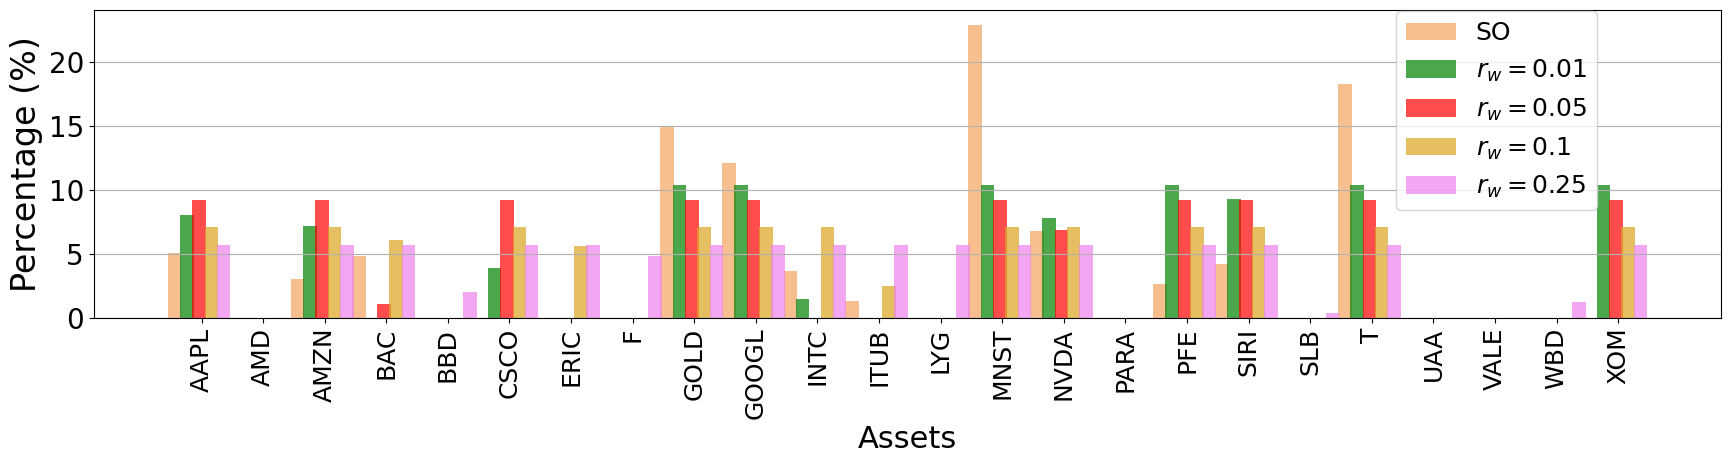

Jis_4=0.3287517007274571
VaR-20.0%=0.02403313818527335
Jis_4=0.4388779182179817
VaR-20.0%=0.02403313818527335
Jis_4=0.521645809610904
VaR-20.0%=0.02403313818527335
Jis_4=0.6649094328202049
VaR-20.0%=0.02403313818527335
Jis_4=0.830843534963686
VaR-20.0%=0.02403313818527335


In [21]:
##ESTOY APENAS REARMANDOLO
#PLOT OPTIMAL PORTFOLIO BASED ON 10Y
 
xdata = np.arange(1, m+1)
alph=0.7
tests=5
width=0.22
radii=[0, 0.01, 0.02, 0.05, 0.1]

print(f"Years 0 to 10")
plt.figure(figsize=(21,4))
colors=['sandybrown','green','red','goldenrod','violet']
for i,_ in enumerate(radii):
    plt.bar(xdata+i*0.2-width*(len(radii)-1)/2, results[f"x_10y_{i}"]*100, width, color=colors[i], alpha=alph)
#plt.xticks(xdata,rotation=90,fontsize=18)
plt.xticks(xdata,assets,rotation=90,fontsize=18)
plt.yticks(fontsize=20)
plt.xlabel('Assets', fontsize=22)
plt.ylabel('Percentage (%)', fontsize=24)
plt.legend(["SO",r'$r_w=0.01$',r'$r_w=0.05$',r'$r_w=0.1$',r'$r_w=0.25$'],loc=[0.8,0.35],fontsize=18)
plt.grid(visible=True,axis='y')
plt.show()
for i,w in enumerate(radii):
    print(f"Jis_{t}={results[f"Jis_{i}_{t}"]}")
    print(f"VaR-{alpha*100}%={tau.get()}") #Value at Risk

#rangg=np.arange(1,tests+1)
#plt.figure(figsize=(14,10))
#plt.plot(rangg,[results[f"Jis_0_{t}"],results["Jis_wr_0.01"+"_"+str(t)],results["Jis_wr_0.05"+"_"+str(t)],results["Jis_wr_0.1"+"_"+str(t)],results["Jis_wr_0.25"+"_"+str(t)]],color='green')
#plt.xticks(rangg,[f"Jis_0_{t}","Jis_wr_0.01"+"_"+str(t),"Jis_wr_0.05"+"_"+str(t),"Jis_wr_0.1"+"_"+str(t),"Jis_wr_0.25"+"_"+str(t)])
#plt.show()


 Years 0 to 5


IndexError: list index out of range

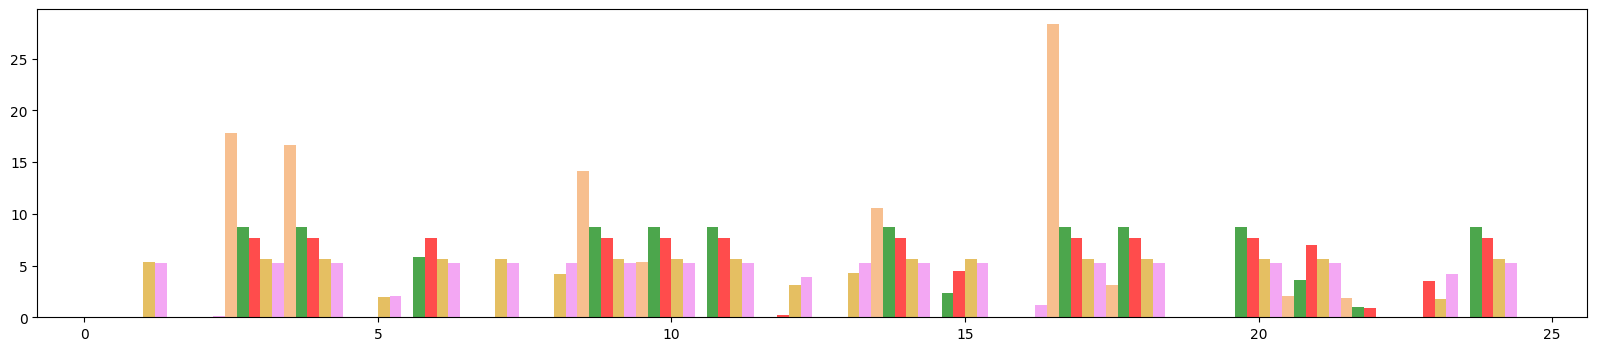

In [55]:
#PLOT OPTIMAL PORTFOLIO SPLIT PER 5 YEARS
 
xdata = np.arange(1, m+1)
alph=0.7
tests=5
width=0.2

for t in range(5): #must guarantuee odd number of test radii
    print(f"\n Years {t} to {t+5}")
    plt.figure(figsize=(20,4))
    colors=['sandybrown','green','red','goldenrod','violet']
    for i,_ in enumerate(radii):
        plt.bar(xdata+i*0.2-width*(len(radii)-1)/2, results[f"x_{i}_{t}"]*100, width, color=colors[i], alpha=alph)
    plt.xticks(xdata,rotation=90,fontsize=18)
    #plt.xticks(xdata,assets,rotation=90,fontsize=18)
    plt.xticks(fontsize=18)
    plt.xlabel('Assets', fontsize=22)
    plt.ylabel('Percentage (%)', fontsize=22)
    plt.legend(["SO",r'$r_w=0.01$',r'$r_w=0.05$',r'$r_w=0.1$',r'$r_w=0.25$'],fontsize=20)
    plt.grid(visible=True,axis='y')
    plt.show()
    for i,w in enumerate(radii):
        print(f"Jis_{t}={results[f"Jis_{i}_{t}"]}")
        print(f"VaR-{alpha*100}%={tau.get()}") #Value at Risk

    #rangg=np.arange(1,tests+1)
    #plt.figure(figsize=(14,10))
    #plt.plot(rangg,[results[f"Jis_0_{t}"],results["Jis_wr_0.01"+"_"+str(t)],results["Jis_wr_0.05"+"_"+str(t)],results["Jis_wr_0.1"+"_"+str(t)],results["Jis_wr_0.25"+"_"+str(t)]],color='green')
    #plt.xticks(rangg,[f"Jis_0_{t}","Jis_wr_0.01"+"_"+str(t),"Jis_wr_0.05"+"_"+str(t),"Jis_wr_0.1"+"_"+str(t),"Jis_wr_0.25"+"_"+str(t)])
    #plt.show()

wr: 0
temp is (5, 24)
wr: 0.01
temp is (5, 24)
wr: 0.02
temp is (5, 24)
wr: 0.05
temp is (5, 24)
wr: 0.1
temp is (5, 24)
wr: 0.2
temp is (5, 24)
Jis is(6, 5)
Joos is (6, 5)


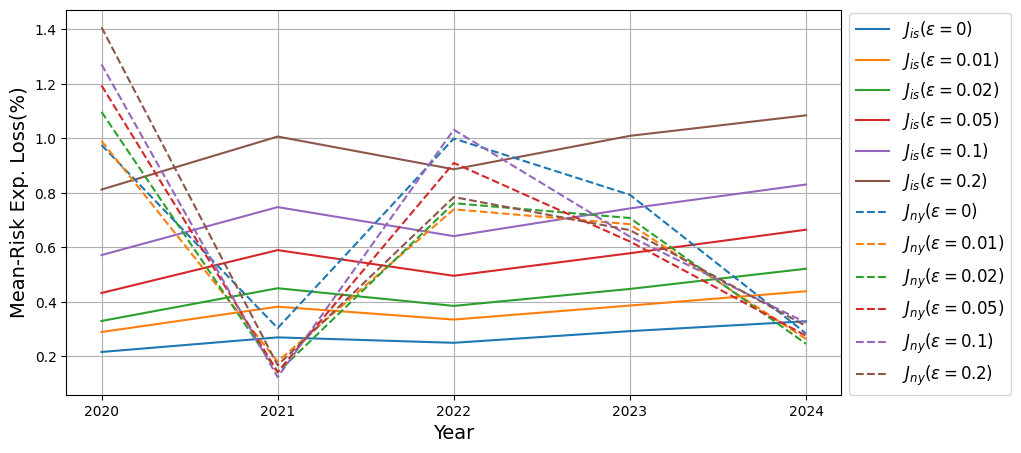

In [68]:
#PLOT OPTIMAL PORTFOLIO AND PERFORMANCE
import pandas as pd
import numpy as np
xdata = np.arange(1, m+1)
alph=0.7
tests=5
width=0.2
colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
plt.figure(figsize=(10,5))
#ax.grid(visible=True)
#ax.legend(loc='upper left',ncol=12,prop={'size':10})
dfs={}
for idx,wr in enumerate(radii):
    print(f"wr: {wr}")
    temp=np.array([results[f"x_{idx}_{t}"] for t in range(5)])
    print(f"temp is {temp.shape}")
    df=pd.DataFrame(temp,columns=assets,index=[i+2020 for i in range(5)])
    #numcols=assets.remove("")
    #df[numcols]=df[numcols].astype(float)
    #print(df.info())
    dfs[f"df_r{idx}"]=df
    #df.plot(x='Year',kind='bar',stacked=True,title='Hallo',ax=ax,width=width)
#ax.legend(loc='upper left',ncol=12,prop={'size':10})
list(dfs.values())
#|print(dfs["df_r0"])

# IN SAMPLE PERFORMANCE
jis=np.array([[results[f"Jis_{i}_{t}"] for t in range(5)] for i,wr in enumerate(radii)])
print(f"Jis is{jis.shape}")


plt.plot([str(2020+i) for i in range(5)],np.transpose(jis))
#plt.legend([fr'$\epsilon=${wr}' for wr in radii])


# Next Year Performance
Joos_avg=np.zeros((len(radii),5))

results["tau_0_0"]
for wridx,wr in enumerate(radii):
    for t in range(5):
        xdec=results[f"x_{wridx}_{t}"]
        tau_=results[f"tau_{wridx}_{t}"]
        Joos_avg[wridx,t]=0
        for m in range(12):
            dot=np.dot(zhat[12*(5+t)+m,:],xdec)
            temp=-dot-tau_
            temp= temp if temp>0 else 0
            Joost=-dot+rho*(tau_+1/alpha*temp)
            Joos_avg[wridx,t]=Joos_avg[wridx,t]+1/12*Joost
print(f"Joos is {Joos_avg.shape}")
#print(Joos_avg)
plt.gca().set_prop_cycle(None)
plt.plot([str(2020+i) for i in range(5)],np.transpose(Joos_avg), linestyle='dashed')
plt.legend([r"$J_{is}(\epsilon=$"+rf"${wr})$"  for wr in radii]+[r"$J_{ny}(\epsilon=$"+rf"${wr})$" for wr in radii],ncol=1,loc=[1.01,0.0],fontsize=12)
plt.grid(visible=True)
plt.xlabel("Year",fontsize=14)
plt.ylabel("Mean-Risk Exp. Loss(%)",fontsize=14)
plt.show()

<Axes: >

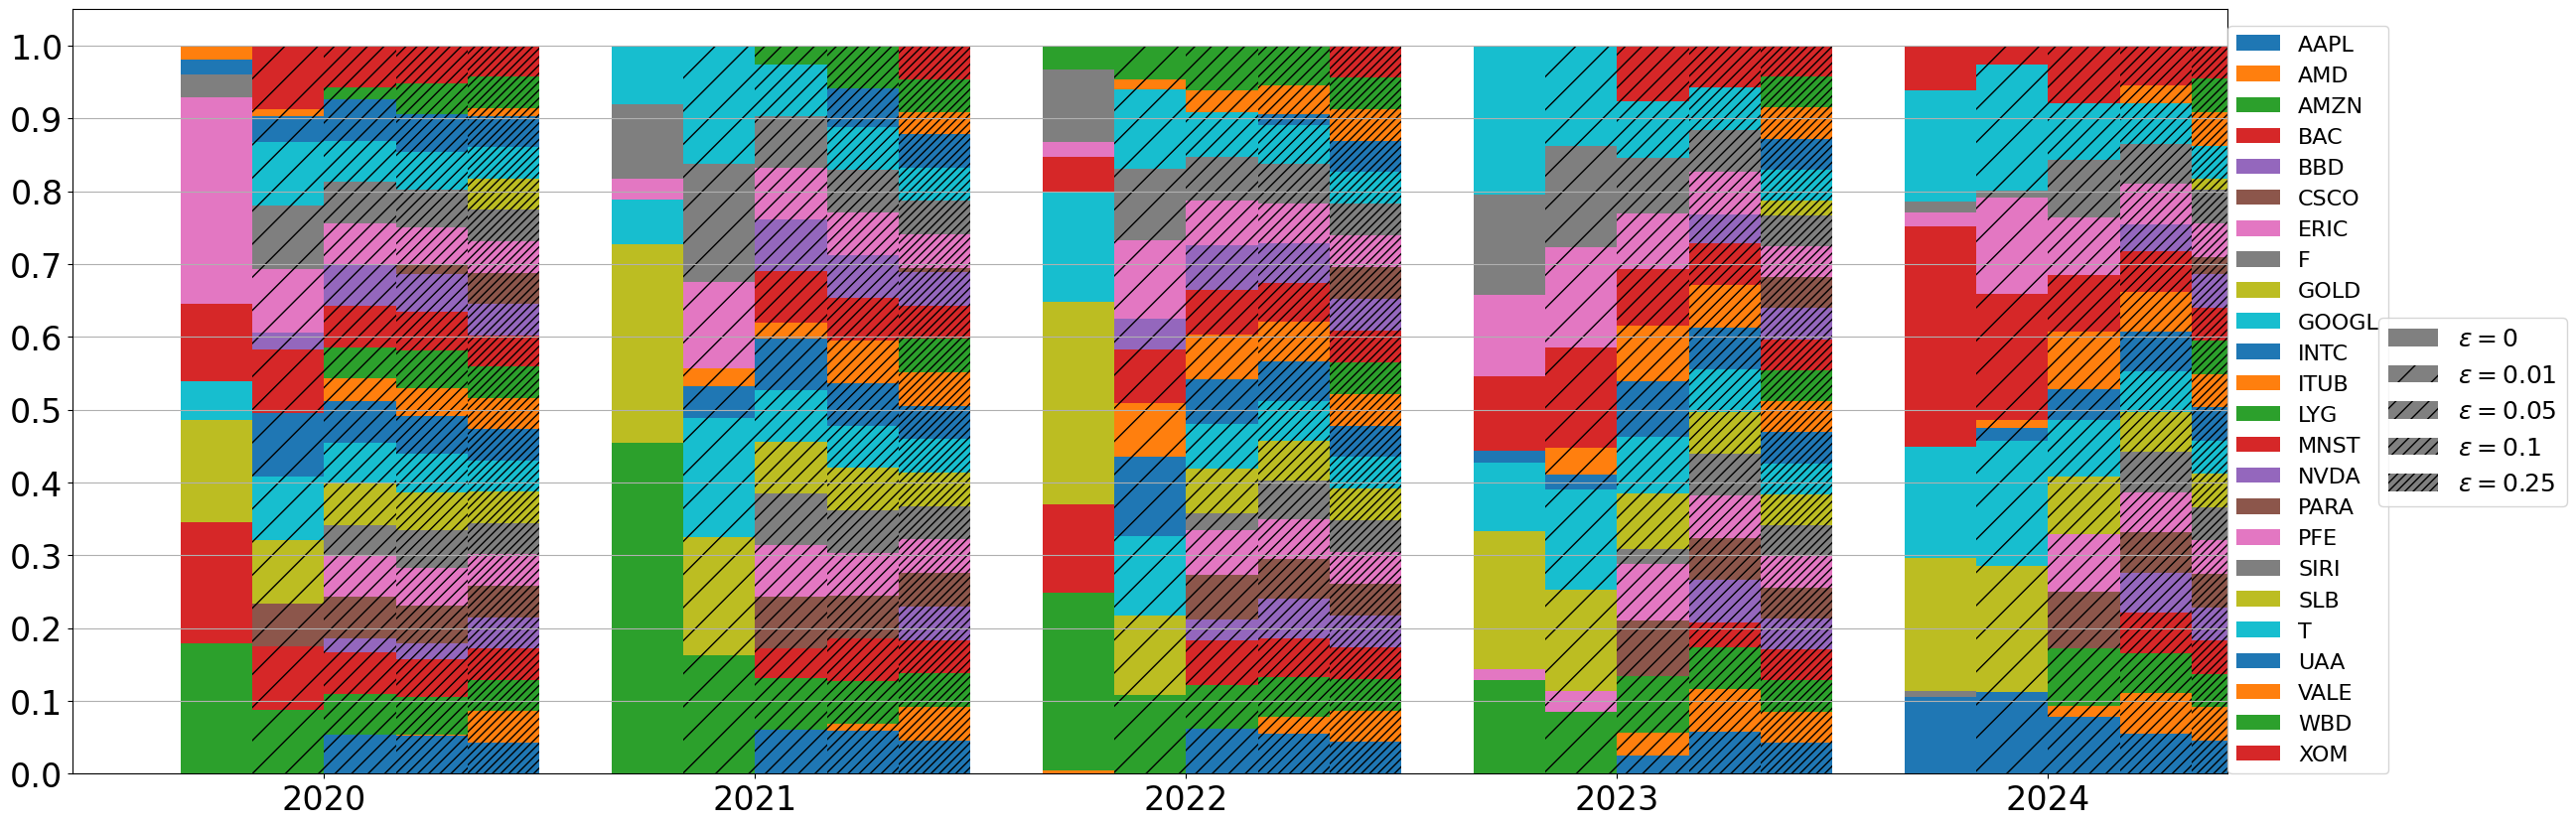

In [551]:
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

def plot_clustered_stacked(dfall, labels=None, title="multiple stacked bar plot",  H="/", **kwargs):
    """Given a list of dataframes, with identical columns and index, create a clustered stacked bar plot. 
labels is a list of the names of the dataframe, used for the legend
title is a string for the title of the plot
H is the hatch used for identification of the different dataframe"""

    n_df = len(dfall)
    n_col = len(dfall[0].columns) 
    n_ind = len(dfall[0].index)
    axe = plt.subplot(111)

    for df in dfall : # for each data frame
        axe = df.plot(kind="bar",
                      linewidth=0,
                      stacked=True,
                      ax=axe,
                      legend=False,
                      grid=False,
                      **kwargs,figsize=(28,10))  # make bar plots

    h,l = axe.get_legend_handles_labels() # get the handles we want to modify
    for i in range(0, n_df * n_col, n_col): # len(h) = n_col * n_df
        for j, pa in enumerate(h[i:i+n_col]):
            for rect in pa.patches: # for each index
                rect.set_x(rect.get_x() + 1 / float(n_df + 1) * i / float(n_col))
                rect.set_hatch(H * int(i / n_col)) #edited part     
                rect.set_width(1 / float(n_df + 1))

    axe.set_xticks((np.arange(0, 2 * n_ind, 2) + 1 / float(n_df + 1)) / 2.)
    axe.set_xticklabels(df.index, rotation = 0,fontsize=24)
    axe.set_title(title,fontsize=24)
    axe.set_yticks(np.arange(0, 1.1, 0.1))
    axe.set_yticklabels([i/10 for i in range(11)],fontsize=24)
    axe.grid(visible=True,axis='y')
    
    # Add invisible data to add another legend
    n=[]        
    for i in range(n_df):
        n.append(axe.bar(0, 0, color="gray", hatch=H * i))

    l1 = axe.legend(h[:n_col], l[:n_col],loc=[1.0, 0.0],fontsize=16)
    if labels is not None:
        l2 = plt.legend(n, labels, loc=[1.07, 0.35],fontsize=18) 
    axe.add_artist(l1)
    #plt.savefig('a',bbox_inches="tight")
    return axe

plot_clustered_stacked(list(dfs.values()),[fr'$\epsilon=${wr}' for wr in radii],H="/",title="")


In [97]:
### Testing against Out-of-sample Performance

NTests=5000
N=5*12
M=500
ii = np.arange(1, m+1)
phi = 0.02 * np.random.normal(size=(M, m))
zeta = 0.03*ii + 0.025*ii*np.random.normal(size=(M, m))
zhat_M = np.maximum(phi + zeta, -1)         # historical data of yearly return
zhat_M[3]

array([ 6.20073396e-02,  8.47001151e-04,  1.00891935e-01,  1.63793041e-01,
        3.30570137e-02,  3.03299009e-01,  3.13128968e-01, -1.25942137e-01,
        3.58943117e-01,  5.08085912e-01,  5.35051948e-01,  5.52541625e-01,
        5.71294279e-01,  9.22287709e-02,  2.55842031e-01,  1.12527924e+00,
       -7.80451147e-02,  3.74350005e-01,  2.72153938e-01,  5.76339213e-01,
        5.07453752e-01,  7.39149016e-01,  1.57883490e+00,  9.80390690e-01])

In [98]:
results={}

for idx,epsilon in enumerate(radii):
    Jis=np.empty(NTests)
    xd=np.empty((NTests,m))
    Joos=np.empty(NTests)

    for j in range(NTests):
        print("test dec #: {j} \n".format(j=j))
        phi = 0.02 * np.random.normal(size=(N, m))
        zeta = 0.03*ii + 0.025*ii*np.random.normal(size=(N, m))
        zhat_N = np.maximum(phi + zeta, -1)         # historical data of yearly return
        SAA_j=DRO(zhat_N,epsilon=epsilon); 
        xd_j=SAA_j["x"] #x_decision from jth sample
        tau_j=SAA_j["tau"]
        Jis_j=SAA_j["J"] #insample performance of jth decision
        print("Jis(xdec)={Jis_j} ".format(Jis_j=Jis_j),end="")

        #outofsample performance of jth decision
        Joos_avg=0
        for i in range(M):
            dot=-np.dot(zhat_M[i],xd_j)
            temp=dot-tau_j
            temp= temp if temp>0 else 0
            Joost=dot+rho*tau_j+rho/alpha*temp
            Joos_avg=Joos_avg+1/M*Joost
        print("Joos(xdec)={Joos_avg} \n".format(Joos_avg=Joos_avg))

        Jis[j]=Jis_j
        xd[j,:]=xd_j
        Joos[j]=Joos_avg
    results[f"Jis_{idx}"]
    results[f"xd_{idx}"]
    results[f"Joos_{idx}"]
#Optimal
    print("---DRO for {M} samples---".format(M=M))
    SAA_full=DRO(zhat_M,epsilon)
    Jstar=SAA_full["J"]
    results[f"Jstar_{idx}"]
    

test dec #: 0 

Solving with Wrad=0 and 60 points
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0179s
Jis(xdec)=-5.046591041182151 Joos(xdec)=-3.8917688338655827 

test dec #: 1 

Solving with Wrad=0 and 60 points
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0194s
Jis(xdec)=-5.100330943989399 Joos(xdec)=-3.8056525194184725 

test dec #: 2 

Solving with Wrad=0 and 60 points
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0265s
Jis(xdec)=-4.325411900647169 Joos(xdec)=-4.035401693622511 

test dec #: 3 

Solving with Wrad=0 and 60 points
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0216s
Jis(xdec)=-5.496095267621006 Joos(xdec)=-4.231563053765918 

test dec #: 4 

Solving with Wrad=0 and 60 points
Being solved by the default LP solver...
Solution status: 0
Running time: 0.0211s
Jis(xdec)=-4.72458587873083 Joos(xdec)=-4.113486613335699 

test dec #: 5 

Solving with Wrad=

KeyError: 'Jis_0'

In [ ]:
nbins=15

plt.hist(Jis, label='Jis', bins=14, alpha=.7, edgecolor='black') 
plt.hist(Joos, label="Joos", bins=14, alpha=.7, edgecolor='black')
plt.axvline(x=Jstar,color='black',label="J*")
plt.axvline(x=np.mean(Jis),color='black',label="Jis-avg")
plt.axvline(x=np.mean(Joos),color='black',label="Joos-avg")
plt.legend()
plt.show()

In [92]:
def DRO(z_hat,epsilon):
    print("Solving with Wrad={epsilon} and {s} points".format(epsilon=epsilon,s=len(z_hat)))

    n=len(z_hat)
    C = - np.eye(m)
    d = np.ones(m)

    model = ro.Model()

    x = model.dvar(m)
    lamb = model.dvar()
    gamma = model.dvar((2, n, m))
    tau = model.dvar()
    s = model.dvar(n)

    model.min(lamb*epsilon + (1/n)*s.sum())
    model.st(x.sum() == 1, x >= 0)
    model.st(b1*tau + a1*(z_hat@x) + (gamma[0]*(1 + z_hat)).sum(axis=1) <= s)
    model.st(b2*tau + a2*(z_hat@x) + (gamma[1]*(1 + z_hat)).sum(axis=1) <= s)
    for i in range(n):
        model.st(rso.norm(-gamma[0, i] - a1*x, 'inf') <= lamb)
        model.st(rso.norm(-gamma[1, i] - a2*x, 'inf') <= lamb)

    model.st(gamma >= 0)

    model.solve()
    return ({"x":x.get(),"J":model.get(),"tau":tau.get()})

## PONENCIA

### Portfolio Optimization
El problema de optimizacion de portafolio es sencillo, queremos minimizar el valor esperado de las pérdidas,  

### Optimizer's Curse
El análisis de alternativas de decision suele involucrar ciertas medidas de valor esperado, como el valor presente neto de un FC, el retorno futuro esperado, la generación solar o eólica esperada, y toma decisiones con respecto a unas estimaciones que se hacen de estas medidas. Es decir, puesto que un análisis de alternativas nunca tiene información perfecta sobre comportamientos futuros, estos estimados de valor esperado están sujetos a errores de estimación. A veces obtendremos subestimados y a veces sobreestimados, pero si asumimos un buen proceso de estimación, sin sesgos, en promedio tenderán a cancelarse estos errores de estimación. Ahora, cuando tomamos decisiones, seleccionamos ciertas alternativas sobre otras. Si los tomadores de decisión usan ciegamente estos estimados, vamos a tender en promedio a preferir decisiones que involucran valores esperados sobreestimados, por lo que al observar los resultados de las decisiones vamos a tender a obtener una diferencia positiva entre el valor esperado dentro-de-la-muestra (o *in-sample*) y el resultado fuera-de-muestra (*out-of-sample*), llamada **out-of-sample disappointment**, es decir, en promedio vamos a quedar decepcionados, no por un sesgo inherente en la estimación, los estudios o análisis, sino por el proceso de selección u optimización en sí. Y claro, este sesgo o decepción será peor si los estimados en sí a parte son optimistas, que suele pasar.

A veces los tomadores de decisión con experiencia son escépticos sobre los resultados de los analistas, y lo reflejan con modificaciones conservadoras como tasas de descuento altas en los flujos de caja o mayor aversión al riesgo, probablemente al haberse topado antes implícitamente con la maldición del optimizador y buscar corregirlo a partir de la experiencia.

De hecho, Smith y Winkler (2006) cuando demostraron este efecto propusieron una solución Bayesiana sencilla, calcular las distribuciones reales condicionado a las distribuciones de los estimados para rankear los valores esperados de las distribuciones resultantes, pero esto requiere asignarle subjetivamente unas incertidumbres a los estimados iniciales, entonces no es ideal.

### DRO as optimal predictor/prescriptor

A veces en la toma de decisiones con base en modelos estadisticos tendemos a desacoplar totalmente los procesos de estimacion de modelos y optimizacion con base en esos estimados, perdiendo de vista el efecto en el sesgo de los errores de estimacion, la maldicion del optimizador que mencioné antes.

Kuhn (2019) propone un esquema mucho más acoplado donde a partir de un conjunto de datos se genera una tupla **predictor** y **prescriptor**. El predictor toma una decisión factible y la distribución empírica construida con los datos y genera un estimado que se usa como aproximación del valor esperado del costo de dicha decisión bajo la distribución real. El predictor induce la existencia de un respectivo prescriptor, que es el argumento que minimiza el costo esperado estimado por el predictor dada una distribución, por lo que determina una decision cuasi-óptima que es una aproximación de la decisión verdaderamente óptima. Un ejemplo familiar de predictor sería el **SAA** (promedio de la muestra), pero el espacio factible de predictores-prescriptores es tan amplio que cobijaría métodos como maximum likelihood, kernel density, construcción de conjuntos de ambiguedad por divergencias, por restricción de momentos, por métricas de probabilidad, entre otros.

Se puede definir un orden parcial en el conjunto factible de tuplas, con base en los estimados de costo esperado de una decisión prescrita para toda distribución en el espacio de distribuciones posibles, y con este orden, se define un problema de meta-optimización para obtener la tupla con menor costo esperado de decisión bajo la restricción de que el **out-of-sample-disappointment** converja de manera exponencial a 0 a medida que el tamaño de la muestra tienda a infinito. Aún sin asignarle una estructura predefinida al predictor, demuestran que la solución óptima es un predictor distribucionalmente robusto al rededor de la distribución empírica. Es decir, DRO transforma un conjunto de datos en decisiones seguras de manera óptima con respecto al **desempeño out-of-sample**.


### Future Work
Las formulaciones distribucionalmente robustas se estan utilizando en estos ultimos años para varios problemas en sistemas de energía eléctrica, uno de ellos es el despacho económico, que es básicamente la programación de los recursos de generación para el día siguiente, y en un escenario de alta penetración de energías renovables es fundamental tratar la incertidumbre de manera explícita. Ya que al usar DROW se puede reducir la diferencia entre desempeño esperado y desempeño real, se pueden reducir las costosas acciones de redespacho. El Ing. Edwin Cervera presenta en esta conferencia una formulación DROW de un problema de despacho económico para microrredes, y nos encontramos trabajando en incluir en la formulación medidas de riesgo sobre las decisiones de despacho, como el costo de los redespachos, de las pérdidas o de la violación de restricciones operativas, para explícitamente minimizar los riesgos económicos u operativos esperados.